Opening dicom images

Getting dicom data I also included the visualisation

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 206
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.14519.5.2.1.6279.6001.225355447149448389850366356384
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.22213.1.143
(0002,0013) Implementation Version Name         SH: '0.5'
(0002,0016) Source Application Entity Title     AE: 'POSDA'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 1.3.6.1.4.1.14519.5.2.1.6279.6001.22535544714944838

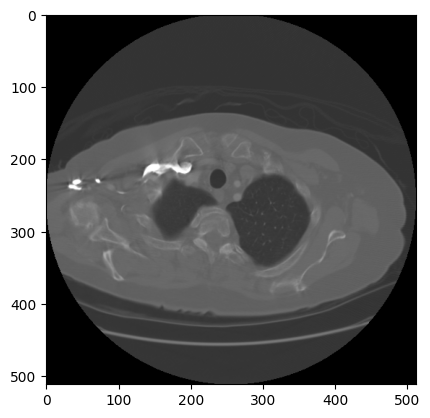

In [34]:
from pathlib import Path 
import os
import numpy as np
import pydicom
import matplotlib.pyplot as plt
import seaborn as sns

project_folder = Path(os.getcwd()).parent.parent
dataset_folder = project_folder / "lidc_idri"
path_to_dicom = dataset_folder / "LIDC-IDRI-0001" / "ad3dac6b-b0b6-4660-b850-438ac41ec18c.dcm"
dicom = pydicom.dcmread(path_to_dicom)
print(dicom)

img = dicom.pixel_array
plt.imshow(img, cmap='gray')

Histogram to visualise range of pixel array

<Axes: ylabel='Count'>

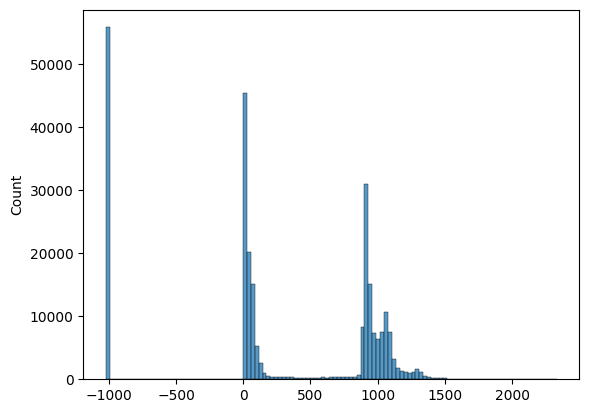

In [20]:
sns.histplot(img.flatten())

From the histogram you can tell you need to scale to HU because it is not scaled

<Axes: ylabel='Count'>

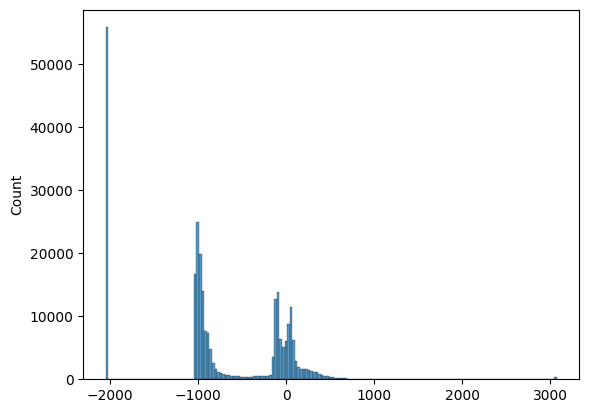

In [41]:
img = dicom.pixel_array
img = int(dicom.RescaleSlope) * img + int(dicom.RescaleIntercept)
sns.histplot(img.flatten())

You can window images with this function

In [39]:
def apply_window(img: np.ndarray, window_level: int, window_width: int) -> np.ndarray:
    upper = window_level + window_width // 2 
    lower = window_level - window_width // 2
    windowed_img = np.clip(img.copy(), lower, upper)
    windowed_img = windowed_img - np.min(windowed_img)
    windowed_img = windowed_img / np.max(windowed_img)
    windowed_img = (windowed_img * 255.0).astype('uint8')
    return windowed_img

Visualise

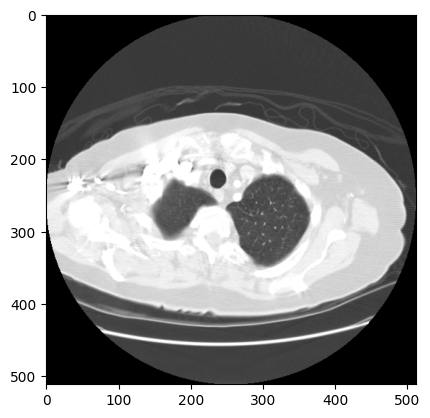

In [43]:
windowed_img = apply_window(img, window_level=-600, window_width=1500)
plt.imshow(windowed_img, cmap='gray')